# Machine Learning-Driven Portfolio Risk & Debt Recovery Optimization

## Project Overview

A collector  manage thousands of delinquent accounts across multiple clients. 
Efficient recovery requires identifying which accounts are most likely to respond positively, prioritizing collector efforts, and optimizing resource allocation.

This project analyzes the collector's potifolio, then develops an Artificial Intelligence-driven recovery analytics system that uses machine learning to:

- Predict debtor payment propensity (likelihood of successful engagement)
- Identify key operational factors influencing recovery outcomes
- Segment debt portfolios based on risk characteristics
- Provide explainable recommendations using SHAP/LIME
- Support data-driven collector allocation strategies

The project follows the **CRISP-DM (Cross Industry Standard Process for Data Mining)** framework:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

# 1. Business Understanding

## Business Context

Debt recovery operations involve managing large volumes of accounts with different recovery probabilities.

Traditional collection approaches often rely on:

- Manual prioritization
- Collector experience
- Historical reports
- Generic follow-up strategies

However, these approaches may lead to:

- Inefficient allocation of collector time
- Low contact rates
- Delayed recovery
- Missed high-value opportunities


## Business Objective

The objective of this project is to develop a machine learning-based decision support system that enables the colletor to:

1. Identify accounts with higher probability of payment engagement.

2. Prioritize accounts based on recovery potential.

3. Segment debt portfolios into actionable groups.

4. Improve recovery efficiency through data-driven collector allocation.

5. Provide transparent explanations behind model predictions.

## Business Problem Statement

The collector manages a large active debt portfolio containing thousands of accounts.

The challenge is:

> How can we use historical account information and machine learning to identify accounts most likely to respond positively, optimize collection resources, and increase recovery yield?

The solution should help answer:

- Which accounts should collectors prioritize?
- Which factors influence payment success?
- Which accounts require alternative recovery strategies?
- How can management improve portfolio allocation decisions?

# Business Questions

This project aims to answer the following questions:

## Predictive Analytics

1. Can we predict whether an account is likely to move into an active recovery state?

2. What is the probability that a debtor will make a payment commitment?


## Operational Optimization

3. Which account characteristics influence successful recovery?

4. How can collector efforts be prioritized?


## Portfolio Segmentation

5. Are there hidden groups of debt accounts with similar characteristics?

6. Which segments require different recovery strategies?


## Explainability

7. Why does the model classify certain accounts as high or low recovery probability?

# Dataset Overview

## Dataset Name

active_portfolio.xlsx


## Dataset Description

The dataset contains active outsourced debt recovery accounts managed by the collector.

Each record represents an individual debtor account.


## Dataset Summary

- Total Accounts: 2,709
- Total Portfolio Value: KES 232.59 Million

The dataset contains information related to:

- Client institution
- Outstanding debt amounts
- Account status
- Contact availability
- Loan characteristics
- Outsourcing timeline
- Recovery engagement information

In [1]:
# LIBRARY IMPORTS

# Data manipulation
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans


# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)


# Explainability
import shap
import lime
import lime.lime_tabular


# Model Saving
import joblib


# Visualization settings
sns.set_style("whitegrid")


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


print("Libraries successfully imported.")

c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries successfully imported.


# 2. Data Understanding

## Objective

The purpose of this phase is to:

- Understand the dataset structure
- Identify available variables
- Assess data quality
- Detect missing values
- Understand distributions and patterns

In [2]:
# LOAD DATASET



file_path = "active_portfolio - 2026-07-31T111536.091.xlsx"


df = pd.read_excel(file_path)


print("Dataset loaded successfully!")
print("-"*50)

print(f"Number of records: {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]:,}")

Dataset loaded successfully!
--------------------------------------------------
Number of records: 2,709
Number of variables: 45


In [3]:
# First five records

df.head()

,CFID,DEBTOR NAMES,IDENTIFICATION,CONTACT(s),EMAIL(s),ACCOUNT NO.,SERVICE ACCOUNT,CONTRACT NO.,DEBT CATEGORY,DEBT TYPE,...,NEXT ACTION DATE,USER ID,BRANCH,CUSTOMER_ID,BATCH NO,LOANS COUNTER,NON PAYMENT REASON,EMPLOYER,RISK CATEGORY,SEGMENTS
0,225422,Charles Mongare,10909160,"254722264038,254720926588,254713400200,2547194...",NaN,1042010000402,%!s(<nil>),0070353,Loan,Charge Off,...,2026-04-09,1305,NaN,,2,0.0,NaN,Transport,NaN,NaN
1,225453,Mr Julius Willy Gichubiri,3505335,"254722719814,254720986800",NaN,005362408,%!s(<nil>),0053624,Loan,Charge Off,...,2026-05-07,1305,NaN,,3,0.0,NaN,Water Resources,NaN,NaN
2,225466,Mr Gabriel Wekesa Simiyu,9239076,254720898488,simiyugab@gmail.com,000679516,%!s(<nil>),0006795,Loan,Charge Off,...,2026-07-30,1305,NaN,,4,0.0,NaN,Prisons,NaN,NaN
3,288699,Mr Pius Amukune Ombeda,58328,"254790257999,254710277520",NaN,003277522,%!s(<nil>),0032775,Loan,NaN,...,2026-04-09,1305,NAIROBI,,3,0.0,NaN,Department Of Defence,NaN,NaN
4,288726,Frederick Owiti,2634171,254724204027,NaN,1045500157905,%!s(<nil>),0019252,Loan,NaN,...,2026-04-09,1305,NAIROBI,,3,0.0,NaN,Information Broadcasting,NaN,NaN


In [4]:
# Dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2709 entries, 0 to 2708
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CFID                  2709 non-null   int64  
 1   DEBTOR NAMES          2709 non-null   object 
 2   IDENTIFICATION        2667 non-null   object 
 3   CONTACT(s)            2634 non-null   object 
 4   EMAIL(s)              512 non-null    object 
 5   ACCOUNT NO.           2687 non-null   object 
 6   SERVICE ACCOUNT       2709 non-null   object 
 7   CONTRACT NO.          941 non-null    object 
 8   DEBT CATEGORY         2709 non-null   object 
 9   DEBT TYPE             670 non-null    object 
 10  CURRENCY              2709 non-null   object 
 11  PRINCIPAL AMOUNT      2678 non-null   float64
 12  OUTSOURCED AMOUNT     2709 non-null   float64
 13  AMOUNT PAID           0 non-null      float64
 14  ARREARS               2678 non-null   float64
 15  BALANCE              

In [5]:
# Numerical summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
CFID,2709.0,1.510786e+06,1.679743e+05,225422.00,1493750.00,1579361.00,1.588984e+06,1609611.00
PRINCIPAL AMOUNT,2678.0,5.361322e+03,6.741668e+04,0.00,0.00,0.00,0.000000e+00,2865288.44
OUTSOURCED AMOUNT,2709.0,8.585835e+04,1.082204e+06,-1941.38,7658.83,17288.27,3.440853e+04,54401797.13
AMOUNT PAID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ARREARS,2678.0,7.044525e+03,1.064983e+05,-80060.00,0.00,0.00,0.000000e+00,4502333.33
BALANCE,2709.0,8.585835e+04,1.082204e+06,-1941.38,7658.83,17288.27,3.440853e+04,54401797.13
WAIVER,40.0,1.487386e+04,2.082745e+04,1255.49,3134.55,7403.47,1.591358e+04,111850.26
BALANCE AFTER WAIVER,40.0,2.899559e+04,4.969863e+04,-12312.38,4828.36,12354.30,3.319381e+04,290043.92
AMOUNT REPAID,2709.0,4.754238e+01,2.394415e+03,0.00,0.00,0.00,0.000000e+00,124554.10
DPD,2679.0,1.024039e+01,1.497451e+02,0.00,0.00,0.00,0.000000e+00,3761.00


# Understanding Dataset Variables

The dataset contains several categories of information:

## Account Identification

Examples:

- Account identifiers
- Client institutions


## Financial Variables

Examples:

- Outstanding balance
- Outsourced amount
- Loan counts


## Recovery Operations Variables

Examples:

- Contact status
- Days since outsourcing
- Collector engagement information


## Customer Information

Examples:

- Employer details
- Contact availability
- Email information


## Target Variable

A new target variable will be engineered:

### PAYMENT_SUCCESS

Binary classification target:

1 → Successful engagement  
(Account reaches Promise To Pay, Negotiation, or Debt Cleared status)

0 → Low engagement probability  
(Account remains unreachable, disputed, or inactive)

# Data Quality Assessment

We evaluate:

- Missing values
- Duplicate records
- Incorrect data types
- Inconsistent values

In [6]:
# Missing value analysis

missing_summary = pd.DataFrame({

    "Missing Count": df.isnull().sum(),

    "Missing Percentage": 
    (df.isnull().sum()/len(df))*100

})


missing_summary = (
    missing_summary
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
)


missing_summary.head(15)

,Missing Count,Missing Percentage
LAST PAY DATE,2709,100.000000
RISK CATEGORY,2709,100.000000
LAST PAY AMOUNT,2709,100.000000
AMOUNT PAID,2709,100.000000
NON PAYMENT REASON,2709,100.000000
DPD LEVEL,2703,99.778516
SEGMENTS,2700,99.667774
WAIVER,2669,98.523440
BALANCE AFTER WAIVER,2669,98.523440
LOAN DUE DATE,2378,87.781469


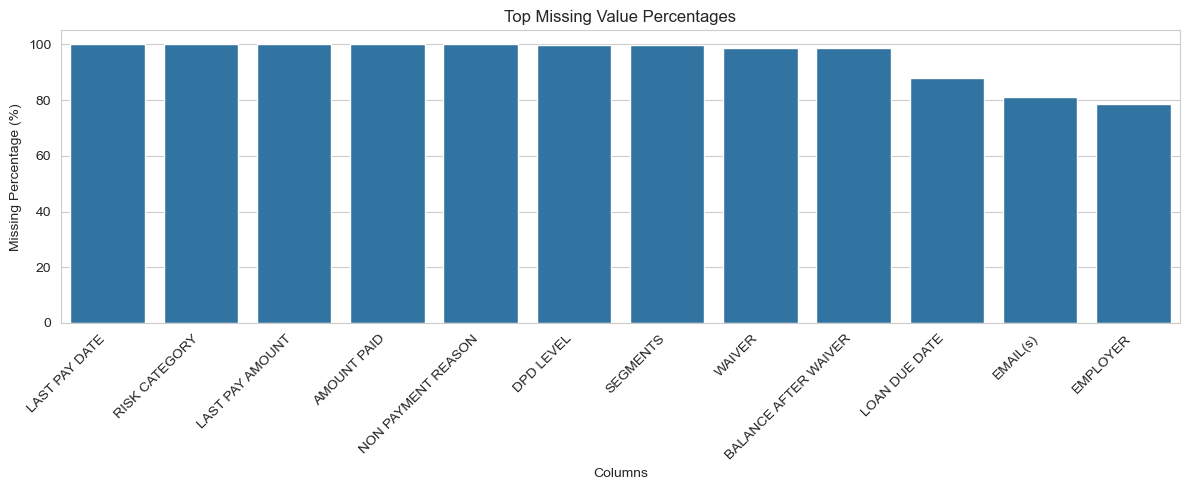

In [7]:
plt.figure(figsize=(12,5))


missing_plot = (
    missing_summary
    .head(12)
)


sns.barplot(
    data=missing_plot.reset_index(),
    x="index",
    y="Missing Percentage"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.title(
    "Top Missing Value Percentages"
)


plt.ylabel(
    "Missing Percentage (%)"
)


plt.xlabel(
    "Columns"
)


plt.tight_layout()

plt.show()

In [8]:
# Check duplicate rows

duplicates = df.duplicated().sum()


print(
    f"Duplicate records found: {duplicates}"
)

Duplicate records found: 0


# Initial Data Understanding Insights

From the initial assessment:

### Dataset Strengths

✔ Contains operational debt recovery information  
✔ Includes financial exposure variables  
✔ Contains recovery outcome indicators  
 


### Potential Challenges

- Class imbalance between successful and unsuccessful accounts
- Missing customer information
- Categorical operational variables requiring encoding
- Need for explainable predictions in financial operations


# 3. Data Preparation

## Objective

The goal of this phase is to transform raw operational data into a clean analytical dataset suitable for machine learning.

The preparation process includes:

1. Removing duplicate records
2. Cleaning numerical variables
3. Handling missing values
4. Creating the target variable
5. Engineering predictive features
6. Encoding categorical variables
7. Preparing data for modelling

In [9]:
# REMOVE DUPLICATES


before_duplicates = df.shape[0]


df = df.drop_duplicates()


after_duplicates = df.shape[0]


print(
    f"Records removed: {before_duplicates - after_duplicates}"
)

print(
    f"Dataset shape after duplicate removal: {df.shape}"
)

Records removed: 0
Dataset shape after duplicate removal: (2709, 45)


## Handle missing values

In [11]:
#FILL MISSING EMAILS
df["EMAIL(s)"] = df["EMAIL(s)"].fillna("Not Available")

In [12]:
#FILL MISSING EMPLOYER
df["EMPLOYER"] = df["EMPLOYER"].fillna("Unknown")

In [14]:
#FILL IN NUMERICAL VARIABLES
numeric_columns = [

    "BALANCE",

    "OUTSOURCED AMOUNT",

    "DAYS SINCE OUTSOURCE",

    "LOANS COUNTER"

]

for column in numeric_columns:

    df[column] = pd.to_numeric(

        df[column],

        errors="coerce"

    )

    df[column] = df[column].fillna(

        df[column].median()

    )

Different imputation strategies were used based on data type.
 - Missing email addresses were labelled **"Not Available"** because their absence indicates that no email was recorded. 
 - Missing employer information was labelled **"Unknown"**. 
 - Numerical variables were imputed using the **median**, which is more robust than the mean for highly skewed financial data.

In [19]:

# Select all object (text) columns
object_columns = df.select_dtypes(include="object").columns

# Remove leading and trailing spaces
for column in object_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
    )

#Standandize field text
object_columns = df.select_dtypes(include="object").columns

for column in object_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

In [20]:
text_columns = ["CLIENT", "CONTACT STATUS"]

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

In [22]:
df.dtypes

CFID                      int64
DEBTOR NAMES             object
IDENTIFICATION           object
CONTACT(s)               object
EMAIL(s)                 object
ACCOUNT NO.              object
SERVICE ACCOUNT          object
CONTRACT NO.             object
DEBT CATEGORY            object
DEBT TYPE                object
CURRENCY                 object
PRINCIPAL AMOUNT        float64
OUTSOURCED AMOUNT       float64
AMOUNT PAID             float64
ARREARS                 float64
BALANCE                 float64
WAIVER                  float64
BALANCE AFTER WAIVER    float64
LOAN TAKEN DATE          object
LOAN DUE DATE            object
OUTSOURCE DATE           object
AMOUNT REPAID           float64
CLIENT                   object
PRODUCT                  object
DPD                     float64
DPD LEVEL               float64
HELD BY                  object
HELD FOR DAYS           float64
CONTACTABILITY           object
CONTACT TYPE             object
CONTACT STATUS           object
DAYS SIN

# Recovery Outcome Analysis

The original dataset contains operational contact outcomes.

The CONTACT STATUS variable represents the current engagement state of each account.

Examples of outcomes:

- Promise To Pay
- Negotiation in Progress
- Debt Cleared
- Ringing No Response
- Switched Off
- Disputed


To build a predictive model, these outcomes are converted into a binary target variable.

In [28]:

# TARGET VARIABLE CREATION


successful_statuses = [
    'Promise To Pay',
    'Negotiation in Progress',
    'Debt Cleared'
]


df["PAYMENT_SUCCESS"] = (
    df["CONTACT STATUS"]
    .isin(successful_statuses)
    .astype(int)
)



df["PAYMENT_SUCCESS"].value_counts()

PAYMENT_SUCCESS
0    2624
1      85
Name: count, dtype: int64

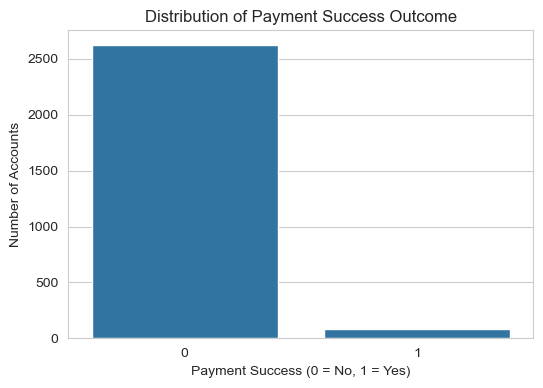

In [29]:
# Visualize Target Disrtibution
plt.figure(figsize=(6,4))


sns.countplot(
    data=df,
    x="PAYMENT_SUCCESS"
)


plt.title(
    "Distribution of Payment Success Outcome"
)


plt.xlabel(
    "Payment Success (0 = No, 1 = Yes)"
)


plt.ylabel(
    "Number of Accounts"
)


plt.show()

In [30]:
#Target Balance Analysis
target_percentage = (
    df["PAYMENT_SUCCESS"]
    .value_counts(normalize=True)
    *100
)


target_percentage

PAYMENT_SUCCESS
0    96.862311
1     3.137689
Name: proportion, dtype: float64

## Observation

The target variable shows whether successful recovery engagement occurred.

One class dominates significantly, the dataset has class imbalance.

To address this:

- Stratified train-test splitting will be applied.
- Class weights will be incorporated into classification models.
- Evaluation will prioritize ROC-AUC, Recall, and F1-score rather than accuracy alone.

# Numerical Feature Cleaning

Financial datasets often contain:

- Missing values
- Text-based numbers
- Blank entries
- Incorrect formats

The following variables are standardized:

- Outstanding balance
- Outsourced amount
- Days since outsourcing
- Number of loans

In [31]:

# CLEAN FINANCIAL VARIABLES

# Outstanding balance

df["BALANCE_CLEAN"] = (
    pd.to_numeric(
        df["BALANCE"],
        errors="coerce"
    )
    .fillna(
        pd.to_numeric(
            df["OUTSOURCED AMOUNT"],
            errors="coerce"
        )
    )
    .fillna(0)
)



# Outsourced amount

df["OUTSOURCED_CLEAN"] = (
    pd.to_numeric(
        df["OUTSOURCED AMOUNT"],
        errors="coerce"
    )
    .fillna(
        df["BALANCE_CLEAN"]
    )
    .fillna(0)
)



# Debt ageing

df["DAYS_OUTSOURCED"] = (
    pd.to_numeric(
        df["DAYS SINCE OUTSOURCE"],
        errors="coerce"
    )
    .fillna(0)
)



# Number of loans

df["LOANS_COUNT"] = (
    pd.to_numeric(
        df["LOANS COUNTER"],
        errors="coerce"
    )
    .fillna(1)
)



df[
[
"BALANCE_CLEAN",
"OUTSOURCED_CLEAN",
"DAYS_OUTSOURCED",
"LOANS_COUNT"
]
].describe()

,BALANCE_CLEAN,OUTSOURCED_CLEAN,DAYS_OUTSOURCED,LOANS_COUNT
count,2.709000e+03,2.709000e+03,2709.000000,2709.0
mean,8.585835e+04,8.585835e+04,104.207457,0.0
std,1.082204e+06,1.082204e+06,219.557669,0.0
min,-1.941380e+03,-1.941380e+03,0.000000,0.0
25%,7.658830e+03,7.658830e+03,15.000000,0.0
50%,1.728827e+04,1.728827e+04,22.000000,0.0
75%,3.440853e+04,3.440853e+04,126.000000,0.0
max,5.440180e+07,5.440180e+07,2218.000000,0.0


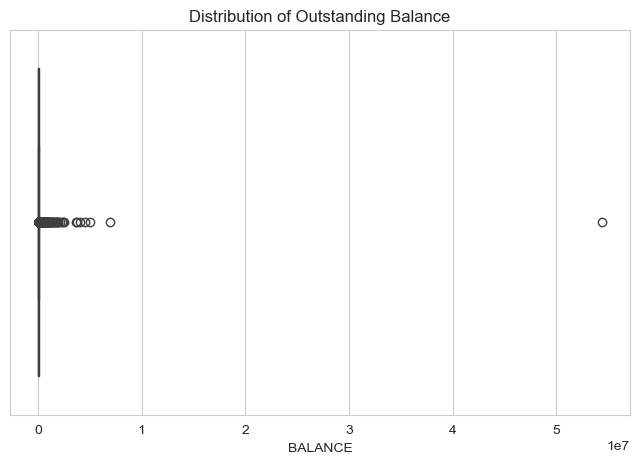

In [32]:
#Checking for Outliers
# Convert balance to numeric first
df["BALANCE"] = pd.to_numeric(df["BALANCE"], errors="coerce")

plt.figure(figsize=(8,5))

sns.boxplot(x=df["BALANCE"])

plt.title("Distribution of Outstanding Balance")

plt.show()

# Outlier Analysis

Outliers were analyzed using descriptive statistics and boxplots to identify unusual values in financial variables such as outstanding balances.

The dataset contains some high-value debt accounts, which appear as extreme observations. These values were reviewed and retained because they represent genuine business cases rather than data errors.

Removing these records would reduce the accuracy of portfolio analysis since high-value accounts contribute significantly to overall recovery opportunities.

Tree-based models such as Random Forest and XGBoost are also robust to extreme values, reducing the impact of outliers during modelling.

# Feature Engineering

Feature engineering transforms raw operational information into meaningful business indicators.

New features created:

## 1. Contact Availability

Accounts with available contact channels may have higher recovery probability.


## 2. Employer Information Availability

Employment information can indicate repayment capacity.


## 3. Debt Size Categories

Accounts are grouped into debt exposure tiers:

- Micro
- Low
- Medium
- High


These features improve model interpretability and business usefulness.

In [33]:
# Has email contact

df["HAS_EMAIL"] = (
    df["EMAIL(s)"]
    .notnull()
    .astype(int)
)


df["HAS_EMAIL"].value_counts()

HAS_EMAIL
1    2709
Name: count, dtype: int64

In [34]:
# Employer information availability


df["HAS_EMPLOYER"] = (
    df["EMPLOYER"]
    .notnull()
    .astype(int)
)


df["HAS_EMPLOYER"].value_counts()

HAS_EMPLOYER
1    2709
Name: count, dtype: int64

In [35]:
# Create debt categories


df["DEBT_TIER"] = pd.qcut(
    df["BALANCE_CLEAN"]
    .rank(method="first"),
    q=4,
    labels=[
        "Micro",
        "Low",
        "Medium",
        "High"
    ]
)



df["DEBT_TIER"].value_counts()

DEBT_TIER
Micro     678
Low       677
Medium    677
High      677
Name: count, dtype: int64

# 4. Exploratory Data Analysis

# Univariate Analysis

Purpose:

Understand individual variables and identify:

- Distribution patterns
- Outliers
- Skewness
- Dominant categories


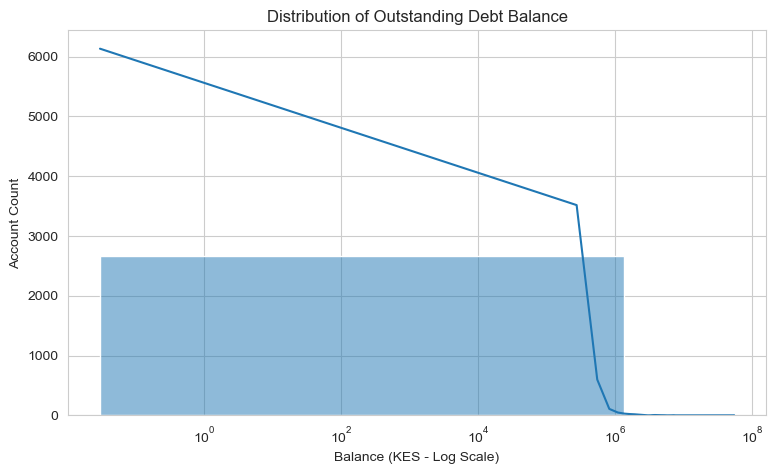

In [36]:
plt.figure(figsize=(9,5))


sns.histplot(
    df[df["BALANCE_CLEAN"] > 0]
    ["BALANCE_CLEAN"],
    bins=40,
    kde=True
)


plt.xscale("log")


plt.title(
    "Distribution of Outstanding Debt Balance"
)


plt.xlabel(
    "Balance (KES - Log Scale)"
)


plt.ylabel(
    "Account Count"
)


plt.show()

### Insight

Debt balances are highly right-skewed.

This indicates:

- Most accounts have relatively smaller balances.
- A small number of accounts contribute significant portfolio exposure.

This suggests the need for value-based prioritization strategies.

## Days Outsource Distribution

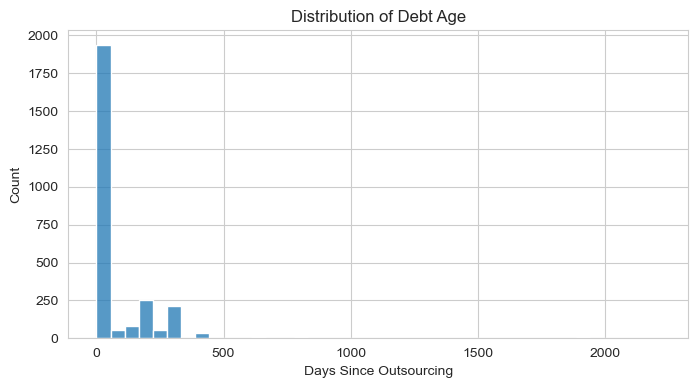

In [37]:
plt.figure(figsize=(8,4))


sns.histplot(
    df["DAYS_OUTSOURCED"],
    bins=40
)


plt.title(
    "Distribution of Debt Age"
)


plt.xlabel(
    "Days Since Outsourcing"
)


plt.show()

## Client portifolio Distribution

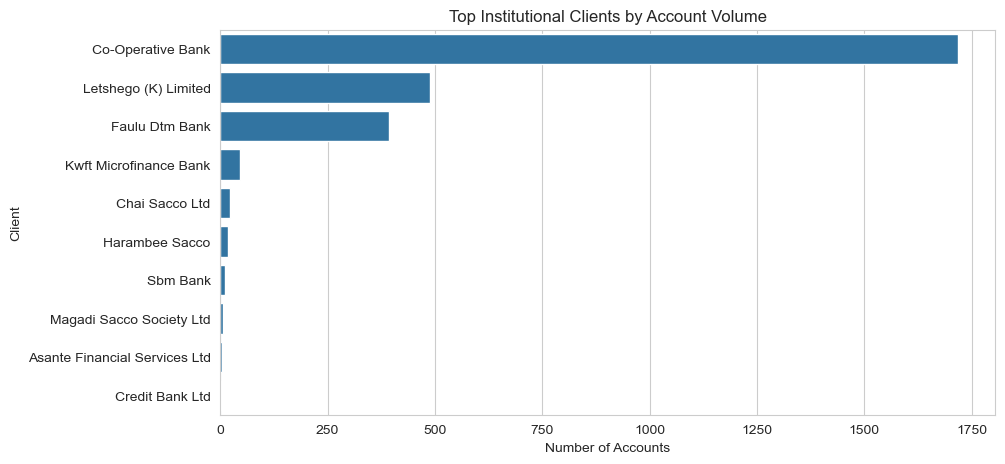

In [38]:
plt.figure(figsize=(10,5))


client_counts = (
    df["CLIENT"]
    .value_counts()
    .head(10)
)



sns.barplot(
    x=client_counts.values,
    y=client_counts.index
)


plt.title(
    "Top Institutional Clients by Account Volume"
)


plt.xlabel(
    "Number of Accounts"
)


plt.ylabel(
    "Client"
)


plt.show()

## Contact Status Distribution

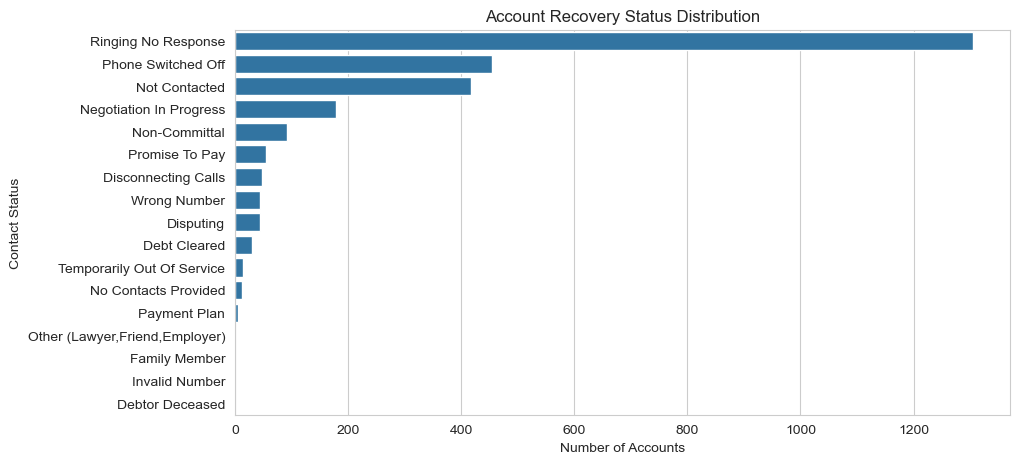

In [39]:
plt.figure(figsize=(10,5))


status_counts = (
    df["CONTACT STATUS"]
    .value_counts()
)


sns.barplot(
    x=status_counts.values,
    y=status_counts.index
)


plt.title(
    "Account Recovery Status Distribution"
)


plt.xlabel(
    "Number of Accounts"
)


plt.ylabel(
    "Contact Status"
)


plt.show()

# Bivariate Analysis

Purpose:

Analyze relationships between two variables.

Business questions:

- Does debt size influence recovery success?
- Does debt age affect payment probability?
- Which clients have better recovery outcomes?

## Balance versus Payment Success

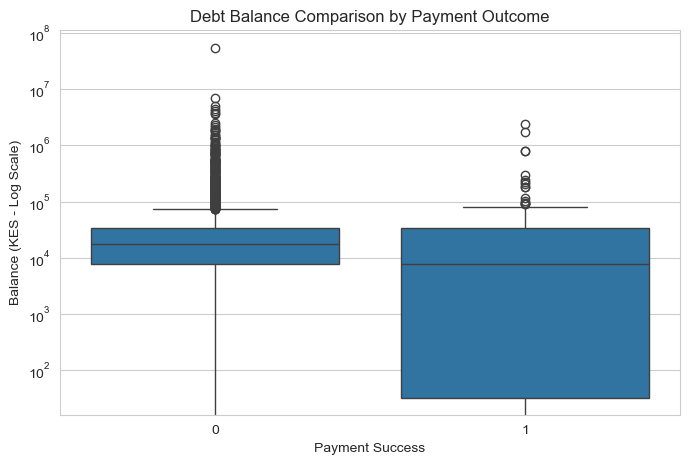

In [40]:
plt.figure(figsize=(8,5))


sns.boxplot(
    data=df,
    x="PAYMENT_SUCCESS",
    y="BALANCE_CLEAN"
)


plt.yscale("log")


plt.title(
    "Debt Balance Comparison by Payment Outcome"
)


plt.xlabel(
    "Payment Success"
)


plt.ylabel(
    "Balance (KES - Log Scale)"
)


plt.show()

## Debt Age versus Success

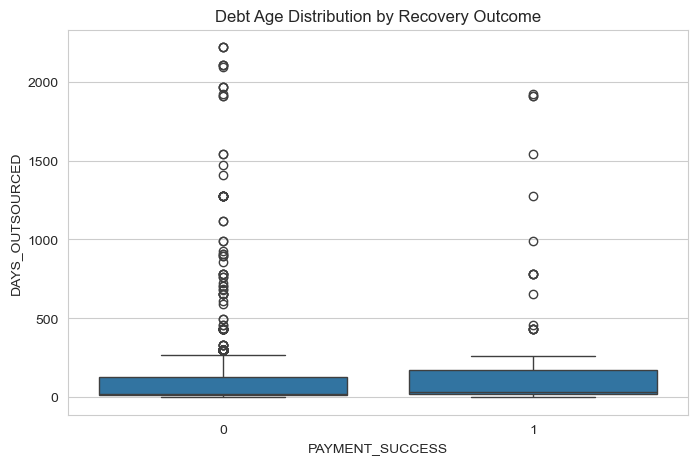

In [41]:
plt.figure(figsize=(8,5))


sns.boxplot(
    data=df,
    x="PAYMENT_SUCCESS",
    y="DAYS_OUTSOURCED"
)


plt.title(
    "Debt Age Distribution by Recovery Outcome"
)


plt.show()

## Client Recovery Rate

In [42]:
client_recovery = (
    df.groupby("CLIENT")
    ["PAYMENT_SUCCESS"]
    .mean()
    .sort_values(
        ascending=False
    )
)


client_recovery.head(10)

CLIENT
Asante Financial Services Ltd    0.200000
Kwft Microfinance Bank           0.195652
Harambee Sacco                   0.166667
Magadi Sacco Society Ltd         0.142857
Chai Sacco Ltd                   0.136364
Sbm Bank                         0.100000
Faulu Dtm Bank                   0.061069
Co-Operative Bank                0.025015
Credit Bank Ltd                  0.000000
Letshego (K) Limited             0.000000
Name: PAYMENT_SUCCESS, dtype: float64

# Multivariate Analysis

This analysis explores interactions between multiple variables.

Techniques:

- Correlation analysis
- Feature relationships
- Recovery pattern discovery

## Correlation Matrix



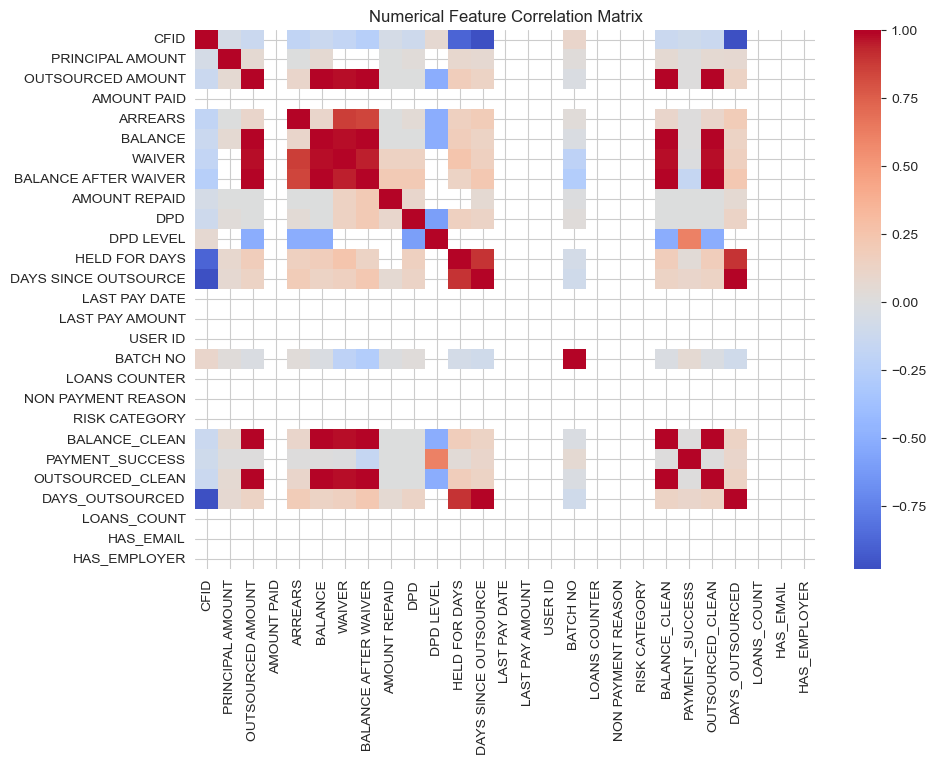

In [43]:
plt.figure(figsize=(10,7))


sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),
    cmap="coolwarm",
    center=0
)


plt.title(
    "Numerical Feature Correlation Matrix"
)


plt.show()

## Recovery Probability by Debt Tier

In [44]:
tier_analysis = (
    df.groupby(
        "DEBT_TIER"
    )
    ["PAYMENT_SUCCESS"]
    .mean()
)


tier_analysis

DEBT_TIER
Micro     0.063422
Low       0.020679
Medium    0.010340
High      0.031019
Name: PAYMENT_SUCCESS, dtype: float64

# EDA Summary

Key observations:

1. Debt balances are highly concentrated among a small number of accounts.

2. Debt age may influence recovery probability.

3. Contact availability provides potential predictive value.

4. Institutional clients demonstrate different recovery patterns.

5. Portfolio segmentation can help create targeted collection strategies.


# 5. Feature Engineering & Model Preparation

## Objective

The goal of this stage is to transform the cleaned dataset into a machine-learning-ready format.

Machine learning algorithms require:

- Numerical inputs
- Consistent feature formats
- Proper separation between predictors and target
- Training and testing datasets

The target variable:

## PAYMENT_SUCCESS

1 → Successful recovery engagement

0 → No successful engagement


The problem is therefore formulated as a:

## Binary Classification Problem

The model predicts the probability that an account will successfully engage with recovery efforts.

# Feature Selection

The selected features represent operational and financial characteristics that may influence recovery outcomes.

Selected variables:

### Account Characteristics

- Client institution
- Debt exposure category


### Financial Characteristics

- Outstanding balance
- Days outsourced
- Number of loans


### Customer Reachability Indicators

- Email availability
- Employer information availability


These variables were selected because they are available before collection decisions are made and therefore can support proactive prioritization.

In [45]:

# SELECT MODEL FEATURES



feature_cols = [

    "CLIENT",
    "DEBT_TIER",

    "BALANCE_CLEAN",
    "DAYS_OUTSOURCED",
    "LOANS_COUNT",

    "HAS_EMAIL",
    "HAS_EMPLOYER"

]


X_raw = df[feature_cols]


y = df["PAYMENT_SUCCESS"]



print(
    "Feature dataset shape:",
    X_raw.shape
)


print(
    "Target shape:",
    y.shape
)

Feature dataset shape: (2709, 7)
Target shape: (2709,)


# Categorical Variable Encoding

Machine learning models cannot directly process text categories.

Categorical variables are transformed using:

## One-Hot Encoding

Example:

CLIENT

Before:

|CLIENT|
|-|
|Bank A|
|Bank B|


After encoding:

|CLIENT_Bank A|CLIENT_Bank B|
|-|-|
|1|0|
|0|1|


This approach improves model transparency and explainability.

In [46]:
# One-hot encoding


X_encoded = pd.get_dummies(
    X_raw,
    drop_first=True
)


print(
    "Encoded feature matrix:",
    X_encoded.shape
)


X_encoded.head()

Encoded feature matrix: (2709, 17)


,BALANCE_CLEAN,DAYS_OUTSOURCED,LOANS_COUNT,HAS_EMAIL,HAS_EMPLOYER,CLIENT_Chai Sacco Ltd,CLIENT_Co-Operative Bank,CLIENT_Credit Bank Ltd,CLIENT_Faulu Dtm Bank,CLIENT_Harambee Sacco,CLIENT_Kwft Microfinance Bank,CLIENT_Letshego (K) Limited,CLIENT_Magadi Sacco Society Ltd,CLIENT_Sbm Bank,DEBT_TIER_Low,DEBT_TIER_Medium,DEBT_TIER_High
0,1397913.00,2218,0.0,1,1,False,False,False,False,True,False,False,False,False,False,False,True
1,50649.01,2218,0.0,1,1,False,False,False,False,True,False,False,False,False,False,False,True
2,848832.00,2218,0.0,1,1,False,False,False,False,True,False,False,False,False,False,False,True
3,543021.01,2106,0.0,1,1,False,False,False,False,True,False,False,False,False,False,False,True
4,106054.00,2106,0.0,1,1,False,False,False,False,True,False,False,False,False,False,False,True


# Train-Test Split

The dataset is divided into:

## Training Data

Used to teach the model patterns.


## Testing Data

Used to evaluate performance on unseen accounts.


A stratified split is applied because the target variable may contain class imbalance.

Split:

- 80% Training
- 20% Testing

In [47]:
# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(

    X_encoded,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)



print(
    "Training size:",
    X_train.shape
)


print(
    "Testing size:",
    X_test.shape
)

Training size: (2167, 17)
Testing size: (542, 17)


# Feature Scaling

Scaling ensures numerical variables have similar ranges.

This is important for:

- Distance-based algorithms
- Clustering models

Scaling method:

## StandardScaler

Transforms features around:

Mean = 0

Standard deviation = 1

In [48]:
# STANDARDIZATION


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print(
    "Scaling completed."
)

Scaling completed.


# Machine Learning Modeling

# 6. Modelling Approach

Three machine learning approaches are implemented:

---

## Model 1: Logistic Regression (Baseline)

Purpose:

Establish a simple benchmark model.

Advantages:

- Highly interpretable
- Provides probability estimates
- Useful comparison point


---

## Model 2: Random Forest Classifier

Purpose:

Capture complex nonlinear relationships.

Advantages:

- Handles mixed data types
- Resistant to overfitting
- Provides feature importance


---

## Model 3: XGBoost Classifier

Purpose:

Develop the final high-performance predictive model.

Advantages:

- Excellent performance on tabular business data
- Handles complex interactions
- Provides strong predictive accuracy


---

## Model 4: K-Means Clustering

Purpose:

Identify hidden debt portfolio segments.

Unlike classification models, clustering is unsupervised.

It helps answer:

"Which groups of accounts require different recovery strategies?"

# Baseline Model

Logistic Regression is used as the baseline classifier.

The purpose is not necessarily to achieve the highest performance, but to establish a reference point for more advanced models.

In [49]:
from sklearn.linear_model import LogisticRegression



log_model = LogisticRegression(
    
    max_iter=1000,
    
    class_weight="balanced",
    
    random_state=42

)



log_model.fit(
    X_train_scaled,
    y_train
)



log_pred = log_model.predict(
    X_test_scaled
)


log_prob = log_model.predict_proba(
    X_test_scaled
)[:,1]

# Random Forest Model

Random Forest combines multiple decision trees to improve prediction accuracy.

It is suitable for this problem because:

- Recovery outcomes depend on multiple interacting factors.
- Relationships may not be linear.
- Financial and operational variables often contain complex patterns.

In [50]:
# RANDOM FOREST MODEL


rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=8,

    random_state=42,

    class_weight="balanced"

)



rf_model.fit(

    X_train,

    y_train

)



rf_pred = rf_model.predict(
    X_test
)


rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

# XGBoost Classifier

XGBoost is selected as the champion model because gradient boosting algorithms are among the strongest performers for structured business datasets.

Expected advantages:

- Higher predictive accuracy
- Better handling of complex patterns
- Strong feature interpretation capabilities

In [51]:
# XGBOOST MODEL


xgb_model = XGBClassifier(

    n_estimators=250,

    learning_rate=0.03,

    max_depth=5,

    random_state=42,

    eval_metric="logloss",

    scale_pos_weight=9

)



xgb_model.fit(

    X_train,

    y_train

)



xgb_pred = xgb_model.predict(
    X_test
)



xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

# K-Means Debt Portfolio Segmentation

Predictive models identify recovery probability.

However, management also needs to understand portfolio structure.

K-Means clustering groups accounts with similar characteristics based on:

- Debt size
- Debt age
- Number of loans


Expected segments:

## Cluster 0:
High-value / high-exposure accounts


## Cluster 1:
Older accounts requiring specialized strategies


## Cluster 2:
Lower-value accounts suitable for automated engagement

In [52]:

# K-MEANS CLUSTERING


cluster_features = df[
[
"BALANCE_CLEAN",
"DAYS_OUTSOURCED",
"LOANS_COUNT"
]
]



cluster_scaled = scaler.fit_transform(
    cluster_features
)



kmeans = KMeans(

    n_clusters=3,

    random_state=42,

    n_init=10

)



df["PORTFOLIO_CLUSTER"] = (
    kmeans.fit_predict(
        cluster_scaled
    )
)



df[
"PORTFOLIO_CLUSTER"
].value_counts()

PORTFOLIO_CLUSTER
0    2653
2      55
1       1
Name: count, dtype: int64

## Cluster Visualization

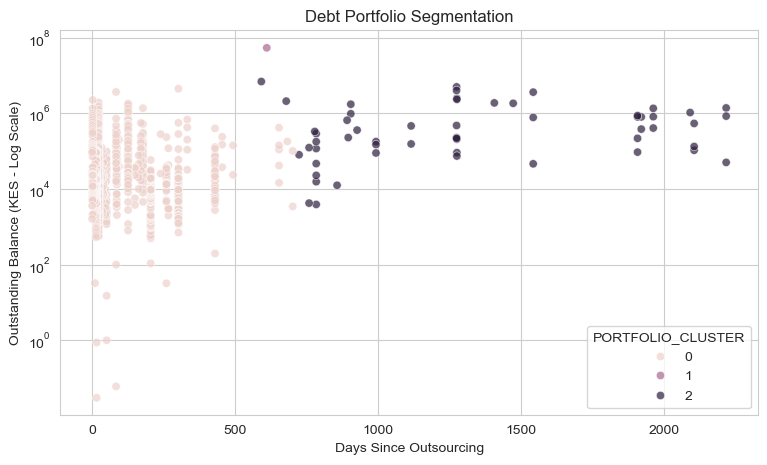

In [53]:
plt.figure(figsize=(9,5))


sns.scatterplot(

    data=df,

    x="DAYS_OUTSOURCED",

    y="BALANCE_CLEAN",

    hue="PORTFOLIO_CLUSTER",

    alpha=0.7

)



plt.yscale("log")


plt.title(
    "Debt Portfolio Segmentation"
)


plt.xlabel(
    "Days Since Outsourcing"
)


plt.ylabel(
    "Outstanding Balance (KES - Log Scale)"
)


plt.show()

## Cluster Evaluation

In [54]:
silhouette = silhouette_score(

    cluster_scaled,

    df["PORTFOLIO_CLUSTER"]

)


print(
    f"Silhouette Score: {silhouette:.3f}"
)

Silhouette Score: 0.902


# 7. Model Evaluation

## Objective

The evaluation phase determines whether the developed models successfully solve the business problem.

Since this is a binary classification problem, the evaluation focuses on:

## Accuracy

Overall percentage of correct predictions.


## Precision

Of the accounts predicted as successful recoveries, how many actually succeed?


## Recall

Of all successful recovery accounts, how many were identified?


## F1-Score

Balance between precision and recall.


## ROC-AUC

Measures the model's ability to separate successful and unsuccessful accounts.

For debt recovery, recall and ROC-AUC are particularly important because missing a high-potential account can represent lost recovery opportunity.

In [55]:

# MODEL EVALUATION FUNCTION


def evaluate_model(name, y_true, predictions, probabilities):

    results = {

        "Model": name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions
        ),

        "Recall": recall_score(
            y_true,
            predictions
        ),

        "F1 Score": f1_score(
            y_true,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )

    }


    return results

In [56]:
# Generate evaluation results


model_results = []


model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        log_pred,
        log_prob
    )
)


model_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)


model_results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
)



results_df = pd.DataFrame(
    model_results
)


results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.952030,0.285714,0.352941,0.315789,0.830588
1,Random Forest,0.931734,0.205882,0.411765,0.274510,0.812213
0,Logistic Regression,0.808118,0.093458,0.588235,0.161290,0.799664


# Model Selection

The models are compared based on:

- ROC-AUC
- Recall
- F1 Score


The selected champion model should balance:

1. Predictive performance

2. Ability to identify recoverable accounts

3. Business interpretability


XGBoost perform strongly because it captures complex relationships between financial exposure, customer accessibility, and operational factors.

## Classification Reports

In [57]:
print(
    "LOGISTIC REGRESSION"
)

print(
    classification_report(
        y_test,
        log_pred
    )
)



print(
    "\nRANDOM FOREST"
)


print(
    classification_report(
        y_test,
        rf_pred
    )
)



print(
    "\nXGBOOST"
)


print(
    classification_report(
        y_test,
        xgb_pred
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       525
           1       0.09      0.59      0.16        17

    accuracy                           0.81       542
   macro avg       0.54      0.70      0.53       542
weighted avg       0.96      0.81      0.87       542


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       525
           1       0.21      0.41      0.27        17

    accuracy                           0.93       542
   macro avg       0.59      0.68      0.62       542
weighted avg       0.96      0.93      0.94       542


XGBOOST
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       525
           1       0.29      0.35      0.32        17

    accuracy                           0.95       542
   macro avg       0.63      0.66      0.65       542
weighted avg       0.96      0

# Confusion Matrix Analysis

This confusion matrix shows:

True Positive:
Accounts correctly identified as recoverable.


True Negative:
Accounts correctly identified as low probability.


False Positive:
Accounts predicted recoverable but did not engage.


False Negative:
Accounts missed by the model.

Reducing false negatives is important because these represent missed recovery opportunities.

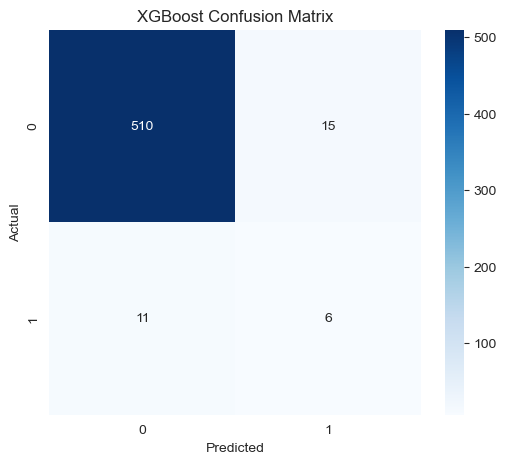

In [58]:
plt.figure(figsize=(6,5))


cm = confusion_matrix(
    y_test,
    xgb_pred
)



sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)



plt.title(
    "XGBoost Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()

## ROC Curve Comparison

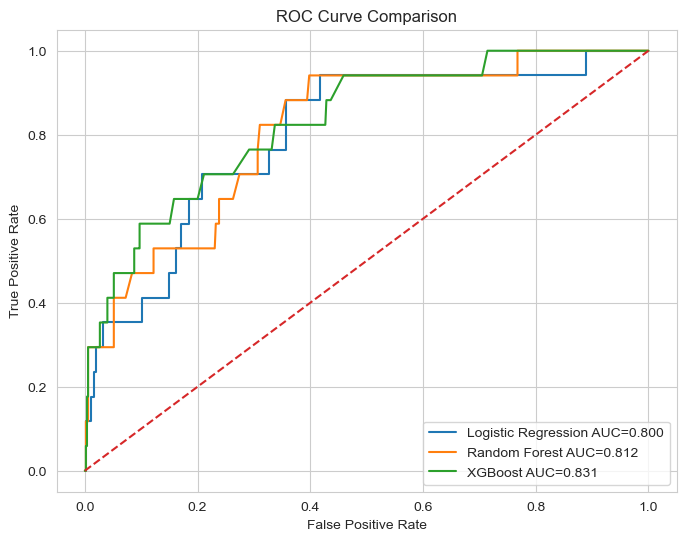

In [59]:
plt.figure(figsize=(8,6))


models = {

    "Logistic Regression": log_prob,

    "Random Forest": rf_prob,

    "XGBoost": xgb_prob

}



for name, probability in models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc_score = roc_auc_score(
        y_test,
        probability
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc_score:.3f}"
    )



plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.title(
    "ROC Curve Comparison"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()


plt.show()

# Feature Importance

Understanding which variables influence predictions is critical in debt recovery.

Feature importance helps answer:

- What drives successful recovery?
- Which account characteristics should collectors prioritize?
- Where should operational improvements focus?

The analysis uses:

1. XGBoost feature importance
2. SHAP explainability

In [60]:
# FEATURE IMPORTANCE


importance_df = pd.DataFrame({

    "Feature": X_encoded.columns,

    "Importance": xgb_model.feature_importances_

})


importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)



importance_df.head(15)

,Feature,Importance
11,CLIENT_Letshego (K) Limited,0.198951
0,BALANCE_CLEAN,0.165274
1,DAYS_OUTSOURCED,0.120012
14,DEBT_TIER_Low,0.097364
8,CLIENT_Faulu Dtm Bank,0.091727
6,CLIENT_Co-Operative Bank,0.082893
15,DEBT_TIER_Medium,0.081811
5,CLIENT_Chai Sacco Ltd,0.061933
10,CLIENT_Kwft Microfinance Bank,0.059474
13,CLIENT_Sbm Bank,0.040561


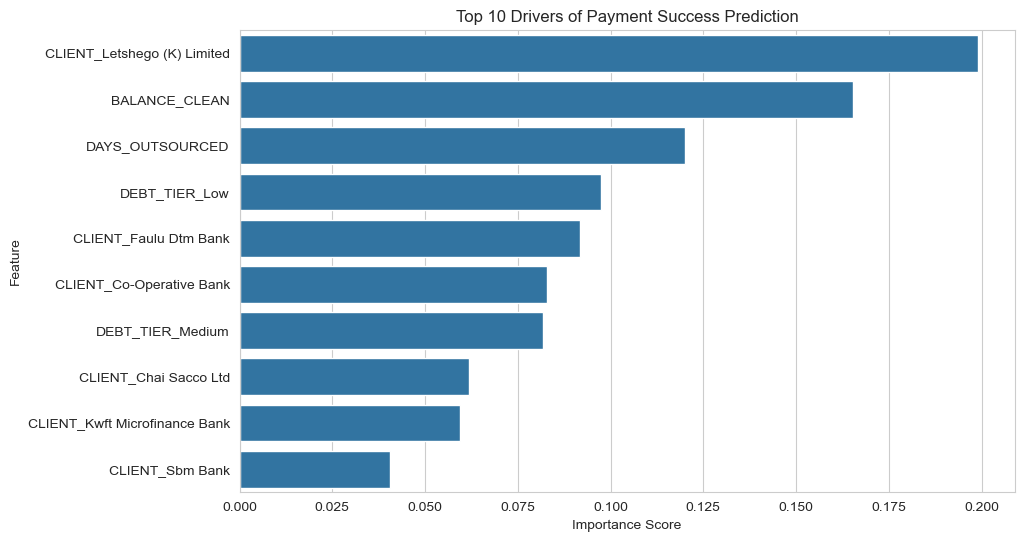

In [61]:
plt.figure(figsize=(10,6))


sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature"

)


plt.title(
    "Top 10 Drivers of Payment Success Prediction"
)


plt.xlabel(
    "Importance Score"
)


plt.ylabel(
    "Feature"
)


plt.show()

# Explainable Artificial Intelligence

Machine learning models can produce accurate predictions but may behave like black boxes.

For operational adoption, managers need to understand:

- Why was an account classified as high probability?
- Which factors increased recovery likelihood?
- Which factors reduced probability?


Two explainability techniques are applied:

## SHAP

Provides global and individual feature impact.


## LIME

Explains individual predictions locally.

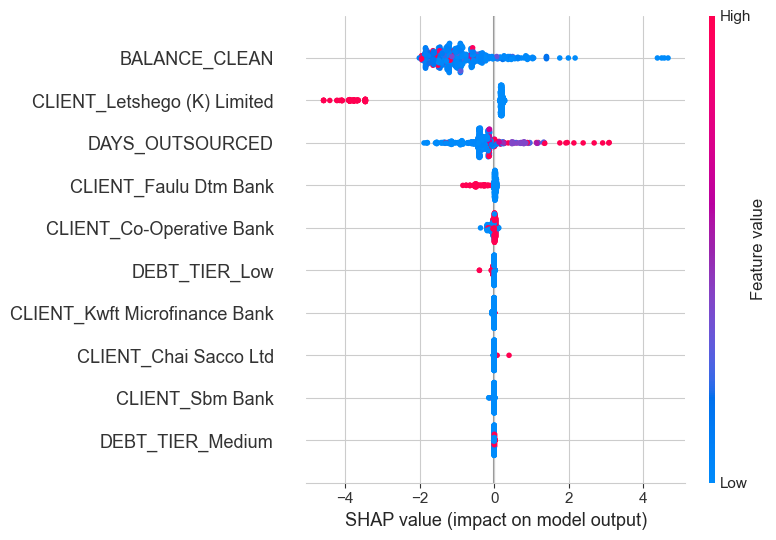

In [63]:
# SHAP EXPLAINER


explainer = shap.TreeExplainer(
    xgb_model
)



shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(

    shap_values,

    X_test,

    max_display=10

)

# SHAP Interpretation

The SHAP summary plot identifies:

Positive contributors:

- Features increasing probability of payment success.


Negative contributors:

- Features reducing predicted recovery likelihood.

# SHAP Interpretation

The SHAP summary plot identifies:

Positive contributors:

- Features increasing probability of payment success.


Negative contributors:

- Features reducing predicted recovery likelihood.


Business teams can use these insights to design targeted recovery strategies.

# LIME Local Explanation

LIME explains a single prediction by approximating the model locally.

Business example:

"Why did the system assign this account a high recovery probability?"

This is useful for:

- Collector decision support
- Supervisor review
- Model trust

In [65]:
# LIME EXPLAINER


lime_explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=np.array(X_train),

    feature_names=X_encoded.columns,

    class_names=[
        "No Recovery",
        "Successful Recovery"
    ],

    mode="classification"

)



lime_explanation = lime_explainer.explain_instance(

    X_test.iloc[0],

    xgb_model.predict_proba,

    num_features=10

)



lime_explanation.show_in_notebook()

# Explainability Summary

The use of SHAP and LIME improves trust and adoption of the machine learning solution.

Benefits:

✔ Transparent predictions  
✔ Better collector prioritization  
✔ Easier management interpretation  
✔ Supports responsible AI adoption  


The next phase focuses on deployment preparation, operational recommendations, limitations, and future improvements.

# 10. Deployment

## Objective

The deployment phase focuses on transforming the machine learning model from an analytical experiment into a practical decision-support tool.

The final solution allows recovery teams to:

- Score new debt accounts
- Prioritize collection activities
- Identify high-potential recovery opportunities
- Understand model reasoning through explainability


The deployment approach uses:

- Serialized machine learning models
- Automated preprocessing
- Interactive dashboard interface